In [ ]:
from sklearn.datasets import load_wine
import pandas as pd
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import RobustScaler

In [ ]:
wine = load_wine()
X = wine.data
y = wine.target

wine_df = pd.DataFrame(data=wine.data, columns=wine.feature_names)
print(wine_df.head())

   alcohol  malic_acid   ash  alcalinity_of_ash  magnesium  total_phenols  \
0    14.23        1.71  2.43               15.6      127.0           2.80   
1    13.20        1.78  2.14               11.2      100.0           2.65   
2    13.16        2.36  2.67               18.6      101.0           2.80   
3    14.37        1.95  2.50               16.8      113.0           3.85   
4    13.24        2.59  2.87               21.0      118.0           2.80   

   flavanoids  nonflavanoid_phenols  proanthocyanins  color_intensity   hue  \
0        3.06                  0.28             2.29             5.64  1.04   
1        2.76                  0.26             1.28             4.38  1.05   
2        3.24                  0.30             2.81             5.68  1.03   
3        3.49                  0.24             2.18             7.80  0.86   
4        2.69                  0.39             1.82             4.32  1.04   

   od280/od315_of_diluted_wines  proline  
0                  

In [ ]:
scalers = {
    'Standard': StandardScaler(), 
    'MinMax': MinMaxScaler(),
    'Robust': RobustScaler(),
}

initialisations = [
    "k-means++", 
    "random"
]

results = []

In [26]:
import matplotlib.pyplot as plt

for scaler_name, scaler in scalers.items():

    X_scaled_version = scaler.fit_transform(X)

    for init_method in initialisations:

        model = KMeans(
            n_clusters=3,
            init=init_method,
            n_init=20,
            random_state=42
        )

        labels = model.fit_predict(
            X_scaled_version
        )

        score = silhouette_score(
            X_scaled_version,
            labels
        )

        results.append({
            "Scaler": scaler_name,
            "Initialization": init_method,
            "Silhouette Score": score
        })

In [27]:
results_df = pd.DataFrame(results)

print(results_df)

     Scaler Initialization  Silhouette Score
0  Standard      k-means++          0.284859
1  Standard         random          0.284859
2    MinMax      k-means++          0.301346
3    MinMax         random          0.300894
4    Robust      k-means++          0.264889
5    Robust         random          0.263688


Standard - k-means++


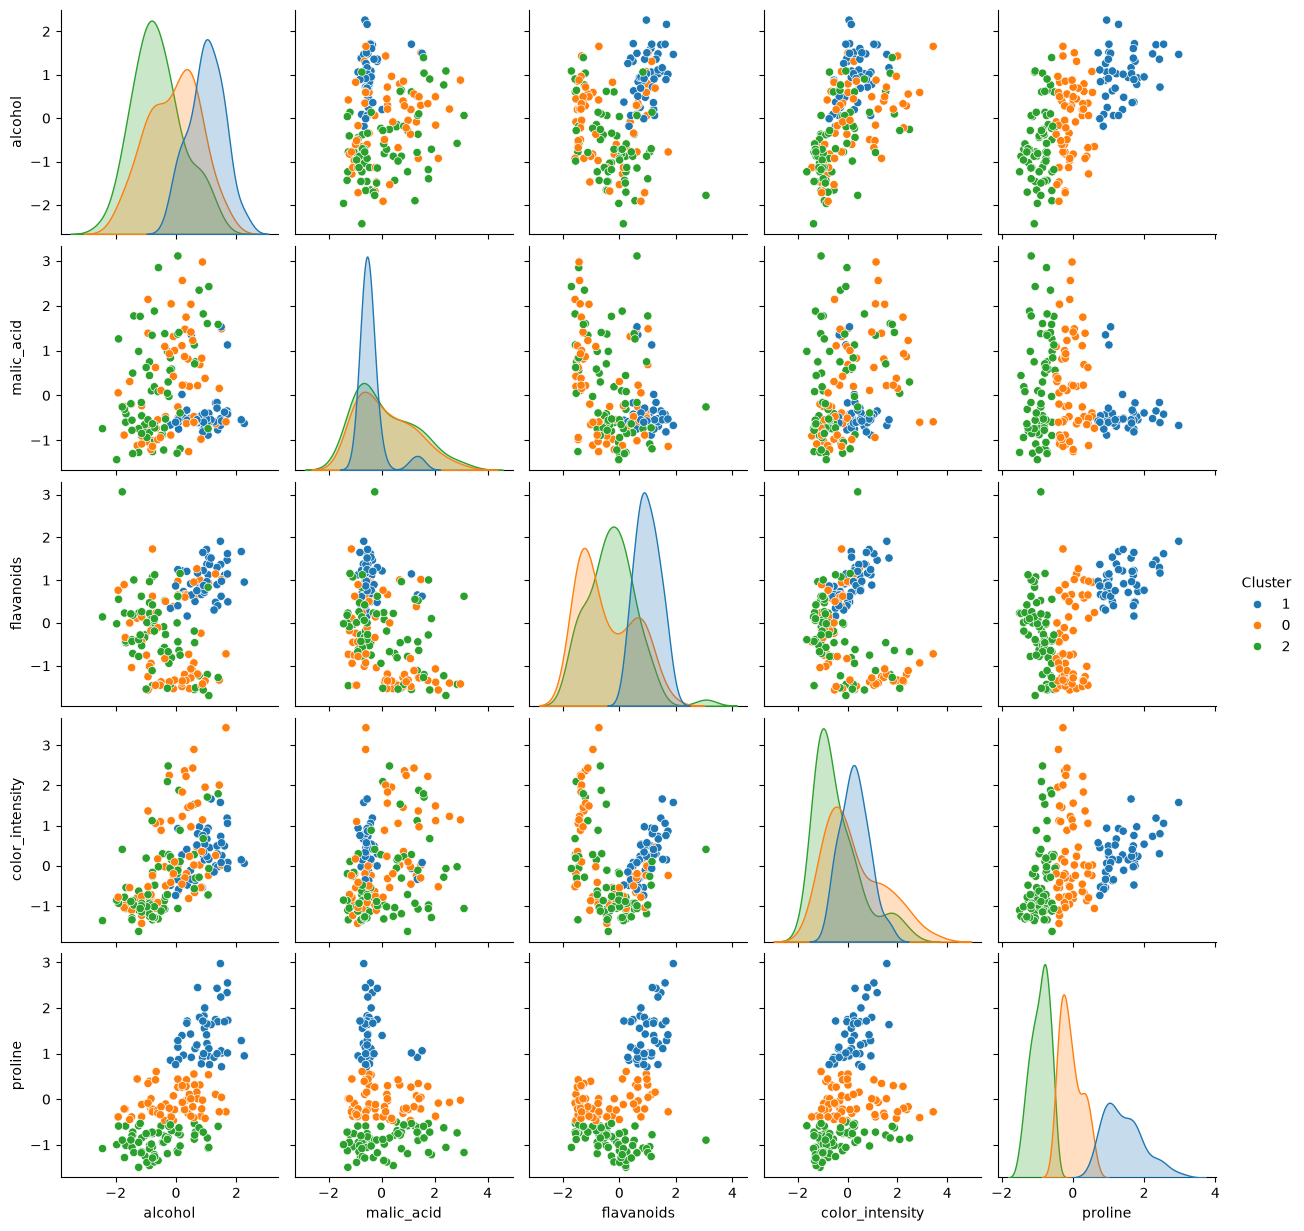

Standard - random


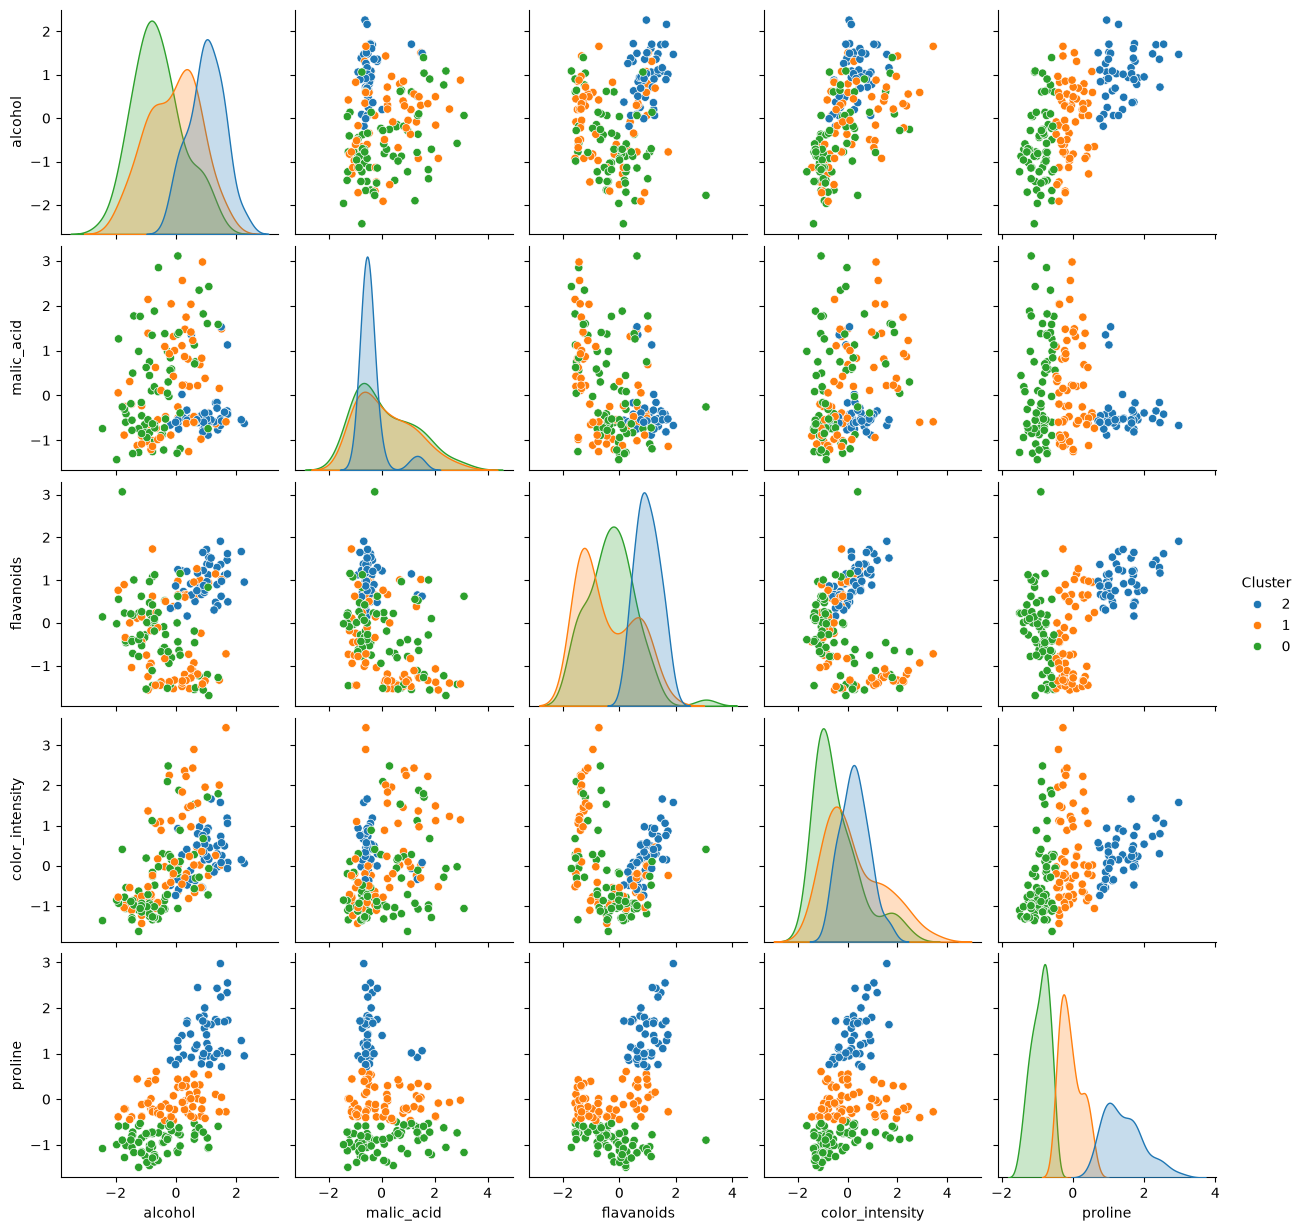

MinMax - k-means++


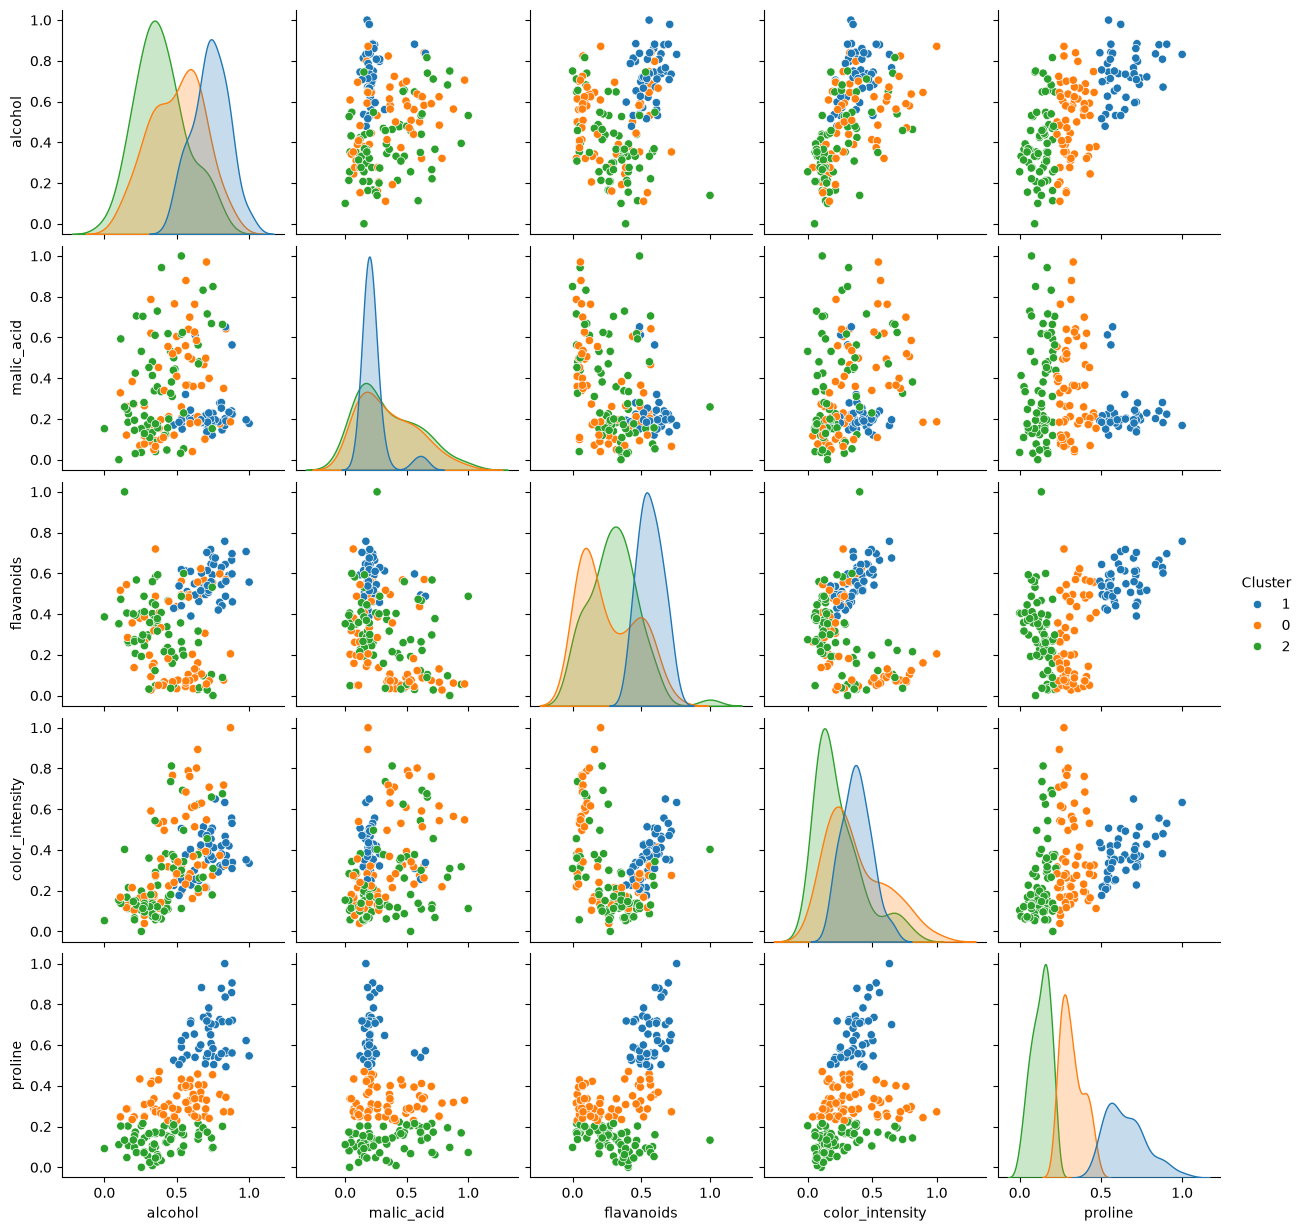

MinMax - random


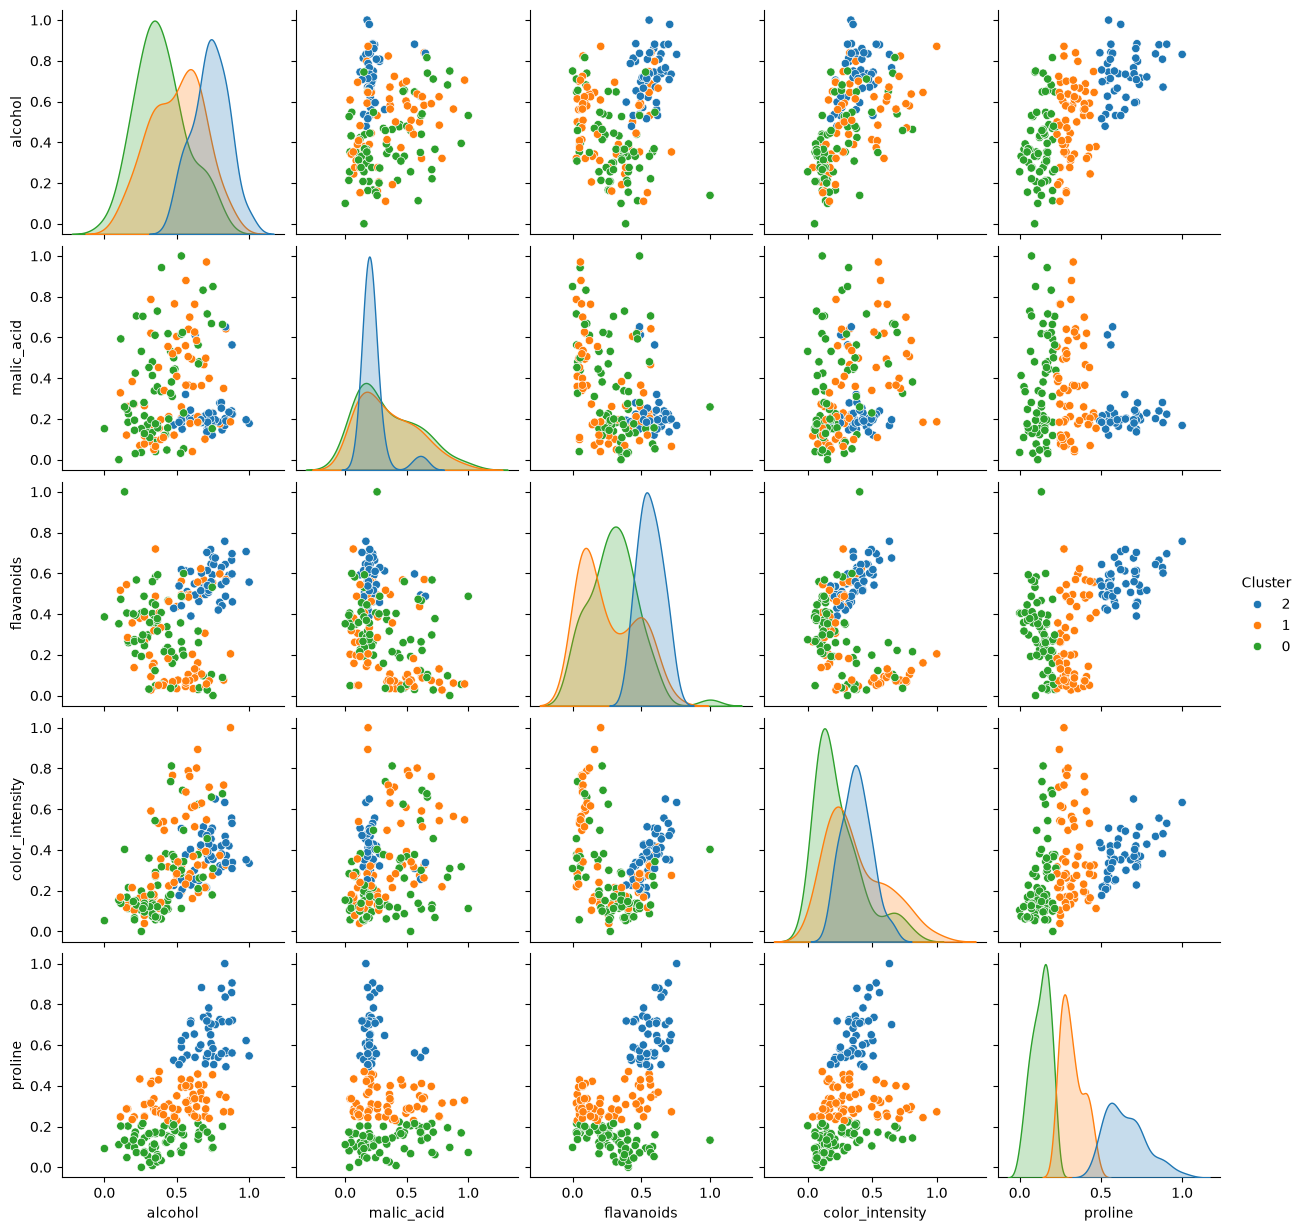

Robust - k-means++


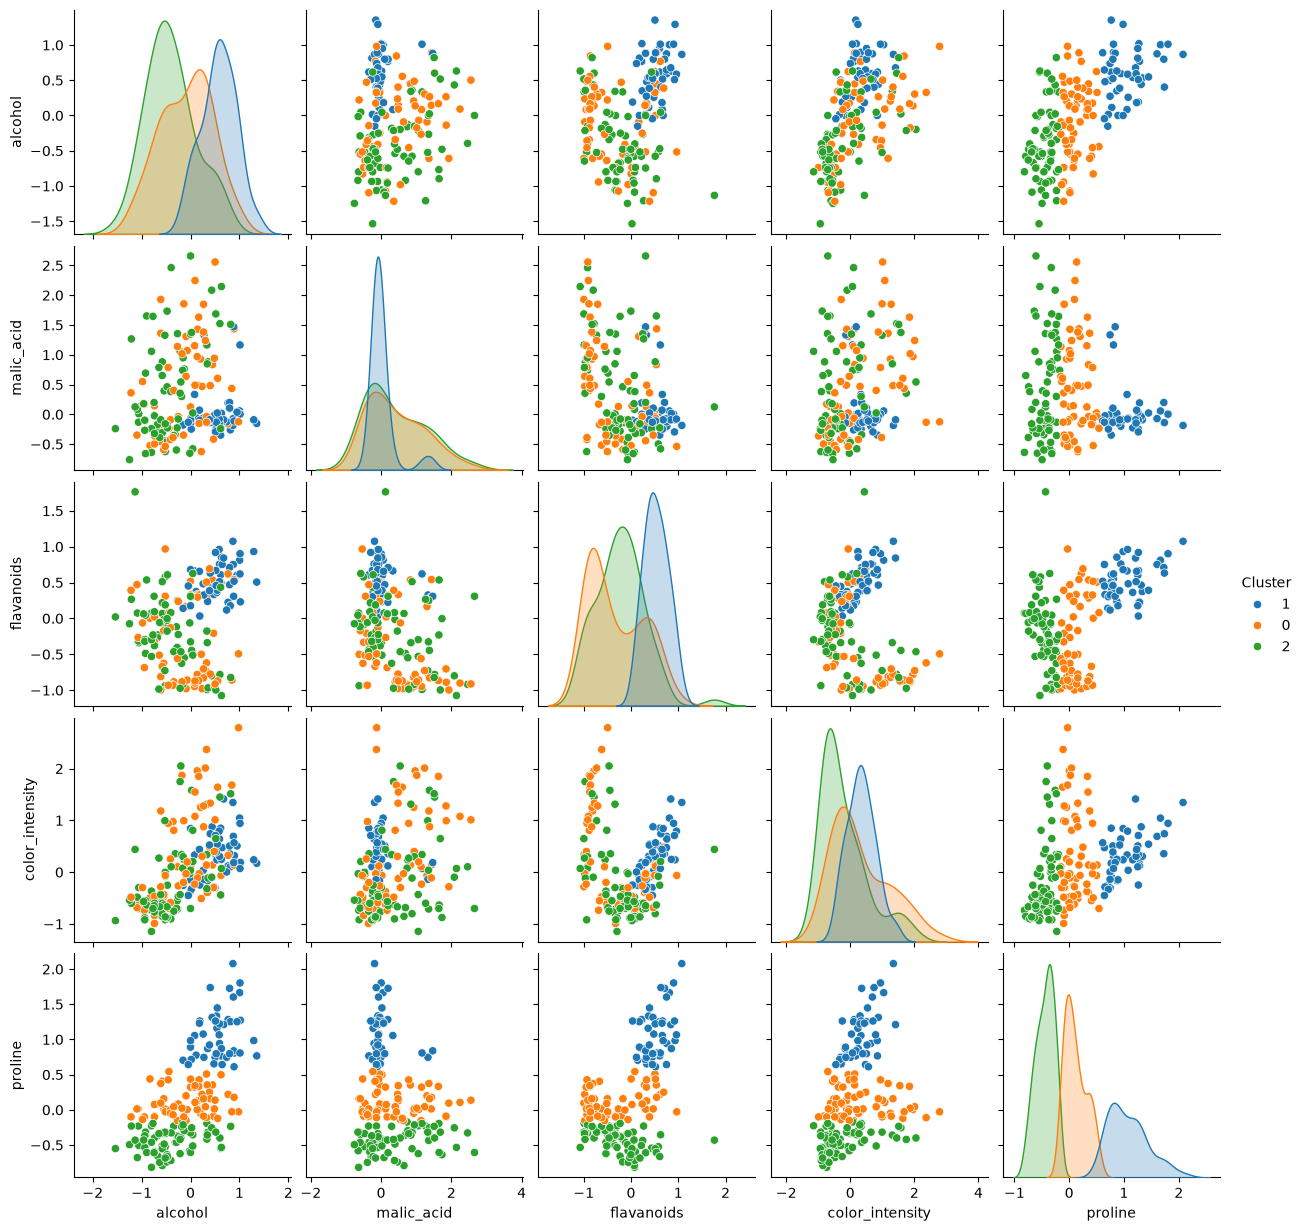

Robust - random


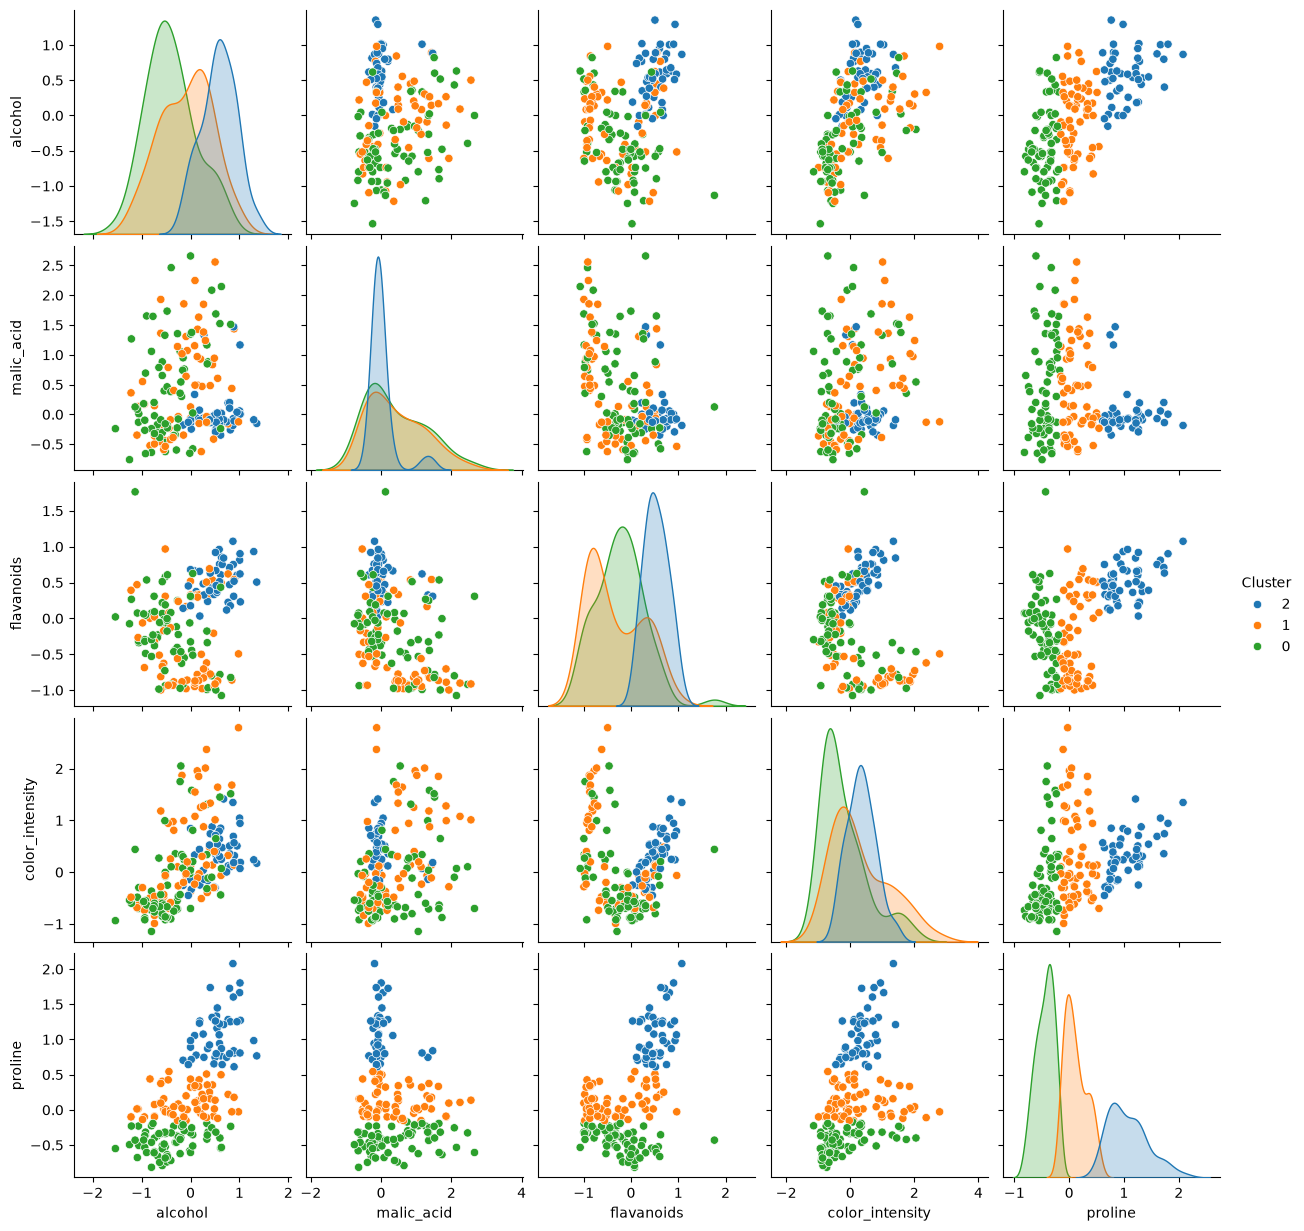

In [30]:
selected_features = [
    "alcohol",
    "malic_acid",
    "flavanoids",
    "color_intensity",
    "proline"
]


for scaler_name, scaler in scalers.items():

    X_scaled_version = scaler.fit_transform(X)

    for init_method in initialisations:

        model = KMeans(
            n_clusters=3,
            init=init_method,
            n_init=20,
            random_state=42
        )

        model.fit(X)

        labels = model.labels_

        plot_df = pd.DataFrame(
            X_scaled_version,
            columns=wine.feature_names
        )

        plot_df["Cluster"] = labels.astype(str)

        print(
            f"{scaler_name} - {init_method}"
        )

        sns.pairplot(
            plot_df[
                selected_features +
                ["Cluster"]
            ],
            hue="Cluster"
        )

        plt.show()